This solution is largely based on [Konstantin Dmitriev's starter model](https://www.kaggle.com/code/kdmitrie/pg501-model-2-decomposition-country-doy-factor?scriptVersionId=220159752). I recommend reading through his notebook first as it provides wonderful explanations for many of the factors included below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import holidays
from sklearn.linear_model import Ridge

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 84af</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.41s</summary>

<pre style='margin: 0;'><code>Cell 84af: % of time = 100.00% 
                                                      (1.253s) out of 1.253s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │import numpy as np                                                                               
      2 │        │       │       │import pandas as pd                                                                              
      3 │    4%  │    8% │   3%  │import matplotlib.pyplot as plt                                                                  
      4 │        │       │       │import datetime as dt                                                                            
      5 │        │       │       │import holidays                                                                                  
      6 │   12%  │   61% │  13%  │from sklearn.linear_model import Ridge                                                           
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

In [3]:
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression

def fit_mape_linear_model(X, y):
    # Ensure X is a 2D array
    X = np.asarray(X)
    y = np.asarray(y).squeeze()
    
    # Add bias term to X
    X = np.column_stack((np.ones(X.shape[0]), X))
    
    # Define the MAPE loss function
    def mape_loss(beta, X, y):
        y_pred = X @ beta
        return np.mean(np.abs((y - y_pred) / y)) * 100
    
    # Initial guess for parameters
    init_params = np.zeros(X.shape[1])
    
    # Minimize the MAPE loss
    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')
    
    # Extract optimized parameters
    beta_opt = result.x
    
    # Create and return an sklearn LinearRegression model
    model = LinearRegression()
    model.coef_ = beta_opt[1:]
    model.intercept_ = beta_opt[0]
    return model

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell e523</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.00s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⏱️ 0.10s</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: LinearRegression, fit_mape_linear_model, minimize</summary>

<pre style='margin: 0;'><code>DiffResult(differences={'LinearRegression': ValueComparison(status='different', value1=None, value2=<class 'sklearn.linear_model._base.LinearRegression'>, message='Variable was added'), 'fit_mape_linear_model': ValueComparison(status='different', value1=None, value2=<function fit_mape_linear_model at 0x2893ce480>, message='Variable was added'), 'minimize': ValueComparison(status='different', value1=None, value2=<function minimize at 0x14f729300>, message='Variable was added')})</code></pre>

</details></div>

In [4]:
train = pd.read_csv('./train.csv', parse_dates=['date'])
test = pd.read_csv('./test.csv', parse_dates=['date'])
train = train.dropna().reset_index(drop=True)
df = pd.concat([train, test], sort=False).reset_index(drop=True)
df

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 725f</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.00s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None</code></pre>

</details></div>

            id       date  ...             product num_sold
0            1 2010-01-01  ...              Kaggle    973.0
1            2 2010-01-01  ...        Kaggle Tiers    906.0
2            3 2010-01-01  ...            Kerneler    423.0
3            4 2010-01-01  ...  Kerneler Dark Mode    491.0
4            5 2010-01-01  ...   Holographic Goose    300.0
...        ...        ...  ...                 ...      ...
319804  328675 2019-12-31  ...   Holographic Goose      NaN
319805  328676 2019-12-31  ...              Kaggle      NaN
319806  328677 2019-12-31  ...        Kaggle Tiers      NaN
319807  328678 2019-12-31  ...            Kerneler      NaN
319808  328679 2019-12-31  ...  Kerneler Dark Mode      NaN

[319809 rows x 6 columns]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.38s</summary>

<pre style='margin: 0;'><code>Cell 725f: % of time = 100.00% 
                                                   (281.083ms) out of 281.083ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    9%  │   46% │  19%  │train = pd.read_csv('./train.csv', parse_dates=['date'])                                         
      2 │    5%  │    4% │   1%  │test = pd.read_csv('./test.csv', parse_dates=['date'])                                           
      3 │    3%  │    6% │   1%  │train = train.dropna().reset_index(drop=True)                                                    
      4 │        │       │       │df = pd.concat([train, test], sort=False).reset_index(drop=True)                                 
      5 │        │       │       │_val = df                                                                                        
      6 │        │       │       │if _val is not None:                                                                             
      7 │    2%  │    3% │   1%  │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: df, test, train</summary>

<pre style='margin: 0;'><code>DiffResult(differences={'train': ValueComparison(status='different', value1=None, value2=            id       date  ...             product num_sold
0            1 2010-01-01  ...              Kaggle    973.0
1            2 2010-01-01  ...        Kaggle Tiers    906.0
2            3 2010-01-01  ...            Kerneler    423.0
3            4 2010-01-01  ...  Kerneler Dark Mode    491.0
4            5 2010-01-01  ...   Holographic Goose    300.0
...        ...        ...  ...                 ...      ...
221254  230125 2016-12-31  ...   Holographic Goose    466.0
221255  230126 2016-12-31  ...              Kaggle   2907.0
221256  230127 2016-12-31  ...        Kaggle Tiers   2299.0
221257  230128 2016-12-31  ...            Kerneler   1242.0
221258  230129 2016-12-31  ...  Kerneler Dark Mode   1622.0

[221259 rows x 6 columns], message='Variable was added'), 'df': ValueComparison(status='different', value1=None, value2=            id       date  ...             product num_sold
0            1 2010-01-01  ...              Kaggle    973.0
1            2 2010-01-01  ...        Kaggle Tiers    906.0
2            3 2010-01-01  ...            Kerneler    423.0
3            4 2010-01-01  ...  Kerneler Dark Mode    491.0
4            5 2010-01-01  ...   Holographic Goose    300.0
...        ...        ...  ...                 ...      ...
319804  328675 2019-12-31  ...   Holographic Goose      NaN
319805  328676 2019-12-31  ...              Kaggle      NaN
319806  328677 2019-12-31  ...        Kaggle Tiers      NaN
319807  328678 2019-12-31  ...            Kerneler      NaN
319808  328679 2019-12-31  ...  Kerneler Dark Mode      NaN

[319809 rows x 6 columns], message='Variable was added'), 'test': ValueComparison(status='different', value1=None, value2=           id       date    country                 store             product
0      230130 2017-01-01     Canada     Discount Stickers   Holographic Goose
1      230131 2017-01-01     Canada     Discount Stickers              Kaggle
2      230132 2017-01-01     Canada     Discount Stickers        Kaggle Tiers
3      230133 2017-01-01     Canada     Discount Stickers            Kerneler
4      230134 2017-01-01     Canada     Discount Stickers  Kerneler Dark Mode
...       ...        ...        ...                   ...                 ...
98545  328675 2019-12-31  Singapore  Premium Sticker Mart   Holographic Goose
98546  328676 2019-12-31  Singapore  Premium Sticker Mart              Kaggle
98547  328677 2019-12-31  Singapore  Premium Sticker Mart        Kaggle Tiers
98548  328678 2019-12-31  Singapore  Premium Sticker Mart            Kerneler
98549  328679 2019-12-31  Singapore  Premium Sticker Mart  Kerneler Dark Mode

[98550 rows x 5 columns], message='Variable was added')})</code></pre>

</details></div>

##### Useful Columns

In [10]:
df['year'] = df['date'].dt.year
df['n_day'] = (df['date'] - df['date'].min()).dt.days
df['weekday'] = df['date'].dt.weekday
df['day_of_year'] = df['date'].dt.dayofyear

# Generate Wave Columns
wave_columns = []
# subtract leap dates
df.loc[df['date'] > dt.datetime(2012, 2, 29), 'n_day'] -= 1
df.loc[df['date'] > dt.datetime(2016, 2, 29), 'n_day'] -= 1

for i in range(1, 10):

    df[f'wave_sin{i}'] = np.sin(np.pi * i * df['n_day'] / 365)
    df[f'wave_cos{i}'] = np.cos(np.pi * i * df['n_day'] / 365)
    wave_columns.append(f'wave_sin{i}')
    wave_columns.append(f'wave_cos{i}')

# Near Holiday
df['near_holiday'] = 0
for country in df['country'].unique():
    days = [day for day in holidays.CountryHoliday(country, years=df['year'].unique())] 
    for day in days:
        df.loc[(df.country == country) & (df['date'].dt.date < day + dt.timedelta(days=10)) & (df['date'].dt.date > day - dt.timedelta(days=10)), 'near_holiday'] = 1

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 02fe</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.09s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 61.44s</summary>

<pre style='margin: 0;'><code>Cell 02fe: % of time = 100.00% 
                                                   (1m:1.359s) out of 1m:1.359s.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │df['year'] = df['date'].dt.year                                                                  
      2 │        │       │       │df['n_day'] = (df['date'] - df['date'].min()).dt.days                                            
      3 │        │       │       │df['weekday'] = df['date'].dt.weekday                                                            
      4 │        │       │       │df['day_of_year'] = df['date'].dt.dayofyear                                                      
      5 │        │       │       │                                                                                                 
      6 │        │       │       │# Generate Wave Columns                                                                          
      7 │        │       │       │wave_columns = []                                                                                
      8 │        │       │       │# subtract leap dates                                                                            
      9 │        │       │       │df.loc[df['date'] > dt.datetime(2012, 2, 29), 'n_day'] -= 1                                      
     10 │        │       │       │df.loc[df['date'] > dt.datetime(2016, 2, 29), 'n_day'] -= 1                                      
     11 │        │       │       │                                                                                                 
     12 │        │       │       │for i in range(1, 10):                                                                           
     13 │        │       │       │                                                                                                 
     14 │        │       │       │    df[f'wave_sin{i}'] = np.sin(np.pi * i * df['n_day'] / 365)                                   
     15 │        │       │       │    df[f'wave_cos{i}'] = np.cos(np.pi * i * df['n_day'] / 365)                                   
     16 │        │       │       │    wave_columns.append(f'wave_sin{i}')                                                          
     17 │        │       │       │    wave_columns.append(f'wave_cos{i}')                                                          
     18 │        │       │       │                                                                                                 
     19 │        │       │       │# Near Holiday                                                                                   
     20 │        │       │       │df['near_holiday'] = 0                                                                           
     21 │        │       │       │for country in df['country'].unique():                                                           
     22 │        │       │       │    days = [day for day in holidays.CountryHoliday(country, years=df['year'].unique())]          
     23 │        │       │       │    for day in days:                                                                             
     24 │   35%  │   62% │   2%  │        df.loc[(df.country == country) & (df['date'].dt.date < day + dt.timedelta(days=10)) & (  
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: country, day, days, df</summary>

<pre style='margin: 0;'><code>DiffResult(differences={'days': ValueComparison(status='different', value1=None, value2=[datetime.date(2016, 1, 1), datetime.date(2016, 2, 8), datetime.date(2016, 2, 9), datetime.date(2016, 7, 6), datetime.date(2016, 9, 12), datetime.date(2016, 3, 25), datetime.date(2016, 5, 1), datetime.date(2016, 5, 21), datetime.date(2016, 8, 9), datetime.date(2016, 10, 29), datetime.date(2016, 12, 25), datetime.date(2016, 5, 2), datetime.date(2016, 12, 26), datetime.date(2017, 1, 1), datetime.date(2017, 1, 28), datetime.date(2017, 1, 29), datetime.date(2017, 6, 25), datetime.date(2017, 9, 1), datetime.date(2017, 4, 14), datetime.date(2017, 5, 1), datetime.date(2017, 5, 10), datetime.date(2017, 8, 9), datetime.date(2017, 10, 18), datetime.date(2017, 12, 25), datetime.date(2017, 1, 2), datetime.date(2017, 1, 30), datetime.date(2017, 6, 26), datetime.date(2018, 1, 1), datetime.date(2018, 2, 16), datetime.date(2018, 2, 17), datetime.date(2018, 6, 15), datetime.date(2018, 8, 22), datetime.date(2018, 3, 30), datetime.date(2018, 5, 1), datetime.date(2018, 5, 29), datetime.date(2018, 8, 9), datetime.date(2018, 11, 6), datetime.date(2018, 12, 25), datetime.date(2019, 1, 1), datetime.date(2019, 2, 5), datetime.date(2019, 2, 6), datetime.date(2019, 6, 5), datetime.date(2019, 8, 11), datetime.date(2019, 4, 19), datetime.date(2019, 5, 1), datetime.date(2019, 5, 19), datetime.date(2019, 8, 9), datetime.date(2019, 10, 27), datetime.date(2019, 12, 25), datetime.date(2019, 5, 20), datetime.date(2019, 8, 12), datetime.date(2019, 10, 28), datetime.date(2010, 1, 1), datetime.date(2010, 2, 14), datetime.date(2010, 2, 15), datetime.date(2010, 9, 10), datetime.date(2010, 11, 17), datetime.date(2010, 4, 2), datetime.date(2010, 5, 1), datetime.date(2010, 5, 28), datetime.date(2010, 8, 9), datetime.date(2010, 11, 5), datetime.date(2010, 12, 25), datetime.date(2010, 2, 16), datetime.date(2011, 1, 1), datetime.date(2011, 2, 3), datetime.date(2011, 2, 4), datetime.date(2011, 8, 30), datetime.date(2011, 11, 6), datetime.date(2011, 4, 22), datetime.date(2011, 5, 1), datetime.date(2011, 5, 17), datetime.date(2011, 8, 9), datetime.date(2011, 10, 26), datetime.date(2011, 12, 25), datetime.date(2011, 5, 2), datetime.date(2011, 11, 7), datetime.date(2011, 12, 26), datetime.date(2011, 5, 7), datetime.date(2012, 1, 1), datetime.date(2012, 1, 23), datetime.date(2012, 1, 24), datetime.date(2012, 8, 19), datetime.date(2012, 10, 26), datetime.date(2012, 4, 6), datetime.date(2012, 5, 1), datetime.date(2012, 5, 5), datetime.date(2012, 8, 9), datetime.date(2012, 11, 13), datetime.date(2012, 12, 25), datetime.date(2012, 1, 2), datetime.date(2012, 8, 20), datetime.date(2013, 1, 1), datetime.date(2013, 2, 10), datetime.date(2013, 2, 11), datetime.date(2013, 8, 8), datetime.date(2013, 10, 15), datetime.date(2013, 3, 29), datetime.date(2013, 5, 1), datetime.date(2013, 5, 24), datetime.date(2013, 8, 9), datetime.date(2013, 11, 2), datetime.date(2013, 12, 25), datetime.date(2013, 2, 12), datetime.date(2014, 1, 1), datetime.date(2014, 1, 31), datetime.date(2014, 2, 1), datetime.date(2014, 7, 28), datetime.date(2014, 10, 5), datetime.date(2014, 4, 18), datetime.date(2014, 5, 1), datetime.date(2014, 5, 13), datetime.date(2014, 8, 9), datetime.date(2014, 10, 22), datetime.date(2014, 12, 25), datetime.date(2014, 10, 6), datetime.date(2015, 1, 1), datetime.date(2015, 2, 19), datetime.date(2015, 2, 20), datetime.date(2015, 7, 17), datetime.date(2015, 9, 24), datetime.date(2015, 4, 3), datetime.date(2015, 5, 1), datetime.date(2015, 6, 1), datetime.date(2015, 8, 9), datetime.date(2015, 11, 10), datetime.date(2015, 12, 25), datetime.date(2015, 8, 10), datetime.date(2015, 8, 7), datetime.date(2015, 9, 11)], message='Variable was added'), 'country': ValueComparison(status='different', value1=None, value2='Singapore', message='Variable was added'), 'day': ValueComparison(status='different', value1=None, value2=datetime.date(2015, 9, 11), message='Variable was added'), 'df': ValueComparison(status='different', value1=            id       date    country  ... wave_sin9 wave_cos9  near_holiday
0            1 2010-01-01     Canada  ...  0.000000  1.000000             0
1            2 2010-01-01     Canada  ...  0.000000  1.000000             0
2            3 2010-01-01     Canada  ...  0.000000  1.000000             0
3            4 2010-01-01     Canada  ...  0.000000  1.000000             0
4            5 2010-01-01     Canada  ...  0.000000  1.000000             0
...        ...        ...        ...  ...       ...       ...           ...
319804  328675 2019-12-31  Singapore  ... -0.077386  0.997001             0
319805  328676 2019-12-31  Singapore  ... -0.077386  0.997001             0
319806  328677 2019-12-31  Singapore  ... -0.077386  0.997001             0
319807  328678 2019-12-31  Singapore  ... -0.077386  0.997001             0
319808  328679 2019-12-31  Singapore  ... -0.077386  0.997001             0

[319809 rows x 29 columns], value2=            id       date    country  ... wave_sin9 wave_cos9  near_holiday
0            1 2010-01-01     Canada  ...  0.000000  1.000000             1
1            2 2010-01-01     Canada  ...  0.000000  1.000000             1
2            3 2010-01-01     Canada  ...  0.000000  1.000000             1
3            4 2010-01-01     Canada  ...  0.000000  1.000000             1
4            5 2010-01-01     Canada  ...  0.000000  1.000000             1
...        ...        ...        ...  ...       ...       ...           ...
319804  328675 2019-12-31  Singapore  ... -0.077386  0.997001             1
319805  328676 2019-12-31  Singapore  ... -0.077386  0.997001             1
319806  328677 2019-12-31  Singapore  ... -0.077386  0.997001             1
319807  328678 2019-12-31  Singapore  ... -0.077386  0.997001             1
319808  328679 2019-12-31  Singapore  ... -0.077386  0.997001             1

[319809 rows x 29 columns], message="Series values mismatch at df['near_holiday'][0]: 0 vs 1")})</code></pre>

</details></div>

In [11]:
### Decomposition

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 6371a060-2818-4605-97af-10fe67b1451b</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.09s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* country: str
* days: List[date]
* day: date</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⏱️ 0.08s</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>↔️ No changes</div>

##### GDP Factor

In [12]:
z = [year for year in df['year'].unique() for country in df['country'].unique()]

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell f857cb90</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.10s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* country: str
* days: List[date]
* day: date</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.21s</summary>

<pre style='margin: 0;'><code>Cell f857cb90: % of time = 100.00%
                                                   (125.555ms) out of 125.555ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    6%  │   71% │  23%  │z = [year for year in df['year'].unique() for country in df['country'].unique()]                 
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>↔️ No changes</div>

In [ ]:

import requests
def get_gdp_per_capita(country,year):
    while True:
        try:
            alpha3 = {'Canada': 'CAN', 'Finland': 'FIN',
                      'Italy': 'ITA', 'Kenya': 'KEN', 
                      'Norway': 'NOR', 'Singapore': 'SGP'}
            url="https://api.worldbank.org/v2/country/{0}/indicator/NY.GDP.PCAP.CD?date={1}&format=json".format(alpha3[country],year)
            print(url)
            response = requests.get(url).json()
            return response[1][0]['value']
        except:
            pass

gdp = np.array([[get_gdp_per_capita(country, year) for year in df['year'].unique()] for country in df['country'].unique()])
gdp_df = pd.DataFrame(gdp, columns=df['year'].unique(), index=df['country'].unique())
for year in df['year'].unique():
    for country in df['country'].unique():
        df.loc[(df['year'] == year) & (df['country'] == country), 'gdp'] = gdp_df.loc[country, year]

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell eb71</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.09s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* country: str
* days: List[date]
* day: date</code></pre>

</details></div>

https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2010&format=json
https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2011&format=json
https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2012&format=json
https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2013&format=json
https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2014&format=json
https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2015&format=json
https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2016&format=json
https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2017&format=json
https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2018&format=json
https://api.worldbank.org/v2/country/CAN/indicator/NY.GDP.PCAP.CD?date=2019&format=json
https://api.worldbank.org/v2/country/FIN/indicator/NY.GDP.PCAP.CD?date=2010&format=json
https://api.worldbank.org/v2/cou

From broccoli beef's [discussion post comment](https://www.kaggle.com/competitions/playground-series-s5e1/discussion/555500#3091632). Using the following least MAPE linear fit improves predictions for kenya.

In [10]:
df['gdp_factor'] =  (-17643.346899+85.42355636*df['gdp']) / 365

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 9e69</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.14s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int32
* country: str</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⏱️ 0.13s</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: df</summary>

<pre style='margin: 0;'><code>{'df': 'DataFrame shape mismatch at df: (319809, 30) vs (319809, 31)'}</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 607c</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.14s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int32
* country: str</code></pre>

</details></div>

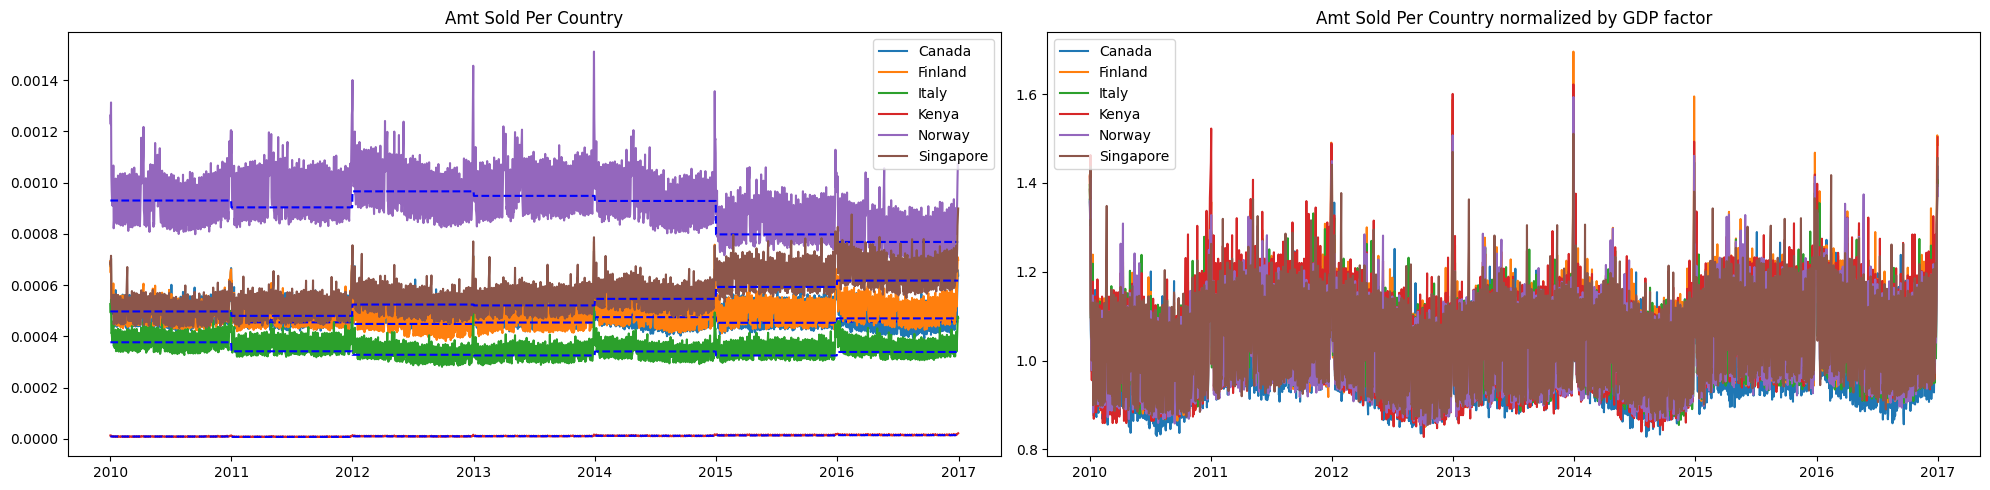

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 5.05s</summary>

<pre style='margin: 0;'><code>Cell 607c: % of time = 100.00%
                                                      (4.884s) out of 4.884s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │   11% │   4%  │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                   
      2 │        │    5% │   1%  │grouped_data = df.groupby(['date', 'year', 'country'])['num_sold'].sum().reset_index()           
      3 │        │       │       │total_per_day = df.groupby('year')['num_sold'].sum().reset_index()                               
      4 │        │       │       │grouped_data = grouped_data.merge(total_per_day, on=['year'], suffixes=['', '_total']).reset_in  
      5 │        │    2% │       │grouped_data = grouped_data.merge(df[['date', 'country', 'gdp_factor']], on=['date', 'country']  
      6 │        │       │       │for country in df['country'].unique():                                                           
      7 │    1%  │    1% │       │    country_data = grouped_data[(grouped_data['country'] == country) & (grouped_data['date'] <   
      8 │        │       │       │    axs[0].plot(country_data['date'], country_data['num_sold'] / country_data['num_sold_total']  
      9 │        │       │       │    axs[0].plot(country_data['date'], country_data['gdp_factor'] / country_data['num_sold_total  
     10 │        │       │       │axs[0].set_title('Amt Sold Per Country')                                                         
     11 │        │       │       │axs[0].legend()                                                                                  
     12 │        │    1% │       │for country in df['country'].unique():                                                           
     13 │    1%  │    1% │       │    country_data = grouped_data[(grouped_data['country'] == country) & (grouped_data['date'] <   
     14 │        │       │       │    axs[1].plot(country_data['date'], country_data['num_sold'] / country_data['gdp_factor'], '-  
     15 │        │       │       │axs[1].set_title('Amt Sold Per Country normalized by GDP factor')                                
     16 │        │       │       │axs[1].legend()                                                                                  
     17 │        │       │       │df['ratio'] = df['gdp_factor']                                                                   
     18 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
     19 │    5%  │   10% │       │plt.tight_layout()                                                                               
     20 │   27%  │   21% │   2%  │_val = plt.show()                                                                                
     21 │        │       │       │if _val is not None:                                                                             
     22 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: country_data, df, grouped_data, total_per_day</summary>

<pre style='margin: 0;'><code>{ 'country_data': 'Variable was added',
  'df': 'DataFrame shape mismatch at df: (319809, 31) vs (319809, 33)',
  'grouped_data': 'Variable was added',
  'total_per_day': 'Variable was added'}</code></pre>

</details></div>

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))
grouped_data = df.groupby(['date', 'year', 'country'])['num_sold'].sum().reset_index()
total_per_day = df.groupby('year')['num_sold'].sum().reset_index()
grouped_data = grouped_data.merge(total_per_day, on=['year'], suffixes=['', '_total']).reset_index()
grouped_data = grouped_data.merge(df[['date', 'country', 'gdp_factor']], on=['date', 'country'])

for country in df['country'].unique():
    country_data = grouped_data[((grouped_data['country'] == country) & (grouped_data['date'] < dt.datetime(2017, 1, 1)))]
    axs[0].plot(country_data['date'], country_data['num_sold'] / country_data['num_sold_total'], '-', label=country)
    axs[0].plot(country_data['date'], country_data['gdp_factor'] / country_data['num_sold_total'], 'b--')
axs[0].set_title('Amt Sold Per Country')
axs[0].legend()

for country in df['country'].unique():
    country_data = grouped_data[((grouped_data['country'] == country) & (grouped_data['date'] < dt.datetime(2017, 1, 1)))]
    axs[1].plot(country_data['date'], country_data['num_sold'] / country_data['gdp_factor'], '-', label=country)
axs[1].set_title('Amt Sold Per Country normalized by GDP factor')
axs[1].legend()

df['ratio'] = df['gdp_factor']
df['total'] = df['num_sold'] / df['ratio']

plt.tight_layout()
plt.show()

##### Store Factor

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 777d</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.16s [removed: axs, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int32
* country: str
* grouped_data: DataFrame[319809 rows; 'index': int64, 'date': datetime64[ns], 'year': int32, 'country': object, 'num_sold': float64, 'num_sold_total': float64, 'gdp_factor': float64]
* total_per_day: DataFrame[10 rows; 'year': int32, 'num_sold': float64]
* country_data: DataFrame[38355 rows; 'index': int64, 'date': datetime64[ns], 'year': int32, 'country': object, 'num_sold': float64, 'num_sold_total': float64, 'gdp_factor': float64]</code></pre>

</details></div>

Store factor sum is 1.0


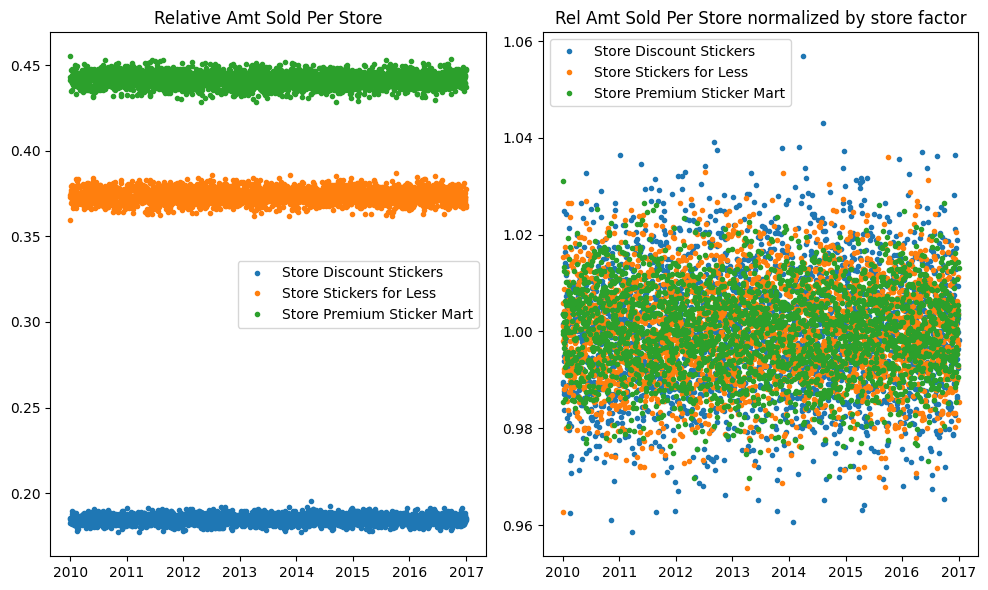

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.21s</summary>

<pre style='margin: 0;'><code>Cell 777d: % of time = 100.00%
                                                      (1.033s) out of 1.033s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    2%  │   29% │   9%  │df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]                                     
      2 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(10, 6))                                                   
      3 │    1%  │    4% │       │store_data = df_no_can_ken.groupby(['date', 'store'])['num_sold'].sum().reset_index()            
      4 │        │       │       │total_per_day = df_no_can_ken.groupby('date')['num_sold'].sum().reset_index()                    
      5 │        │       │       │store_data = store_data.merge(total_per_day, on=['date'], suffixes=['', '_total'])               
      6 │        │       │       │store_data['store_factor'] = store_data['num_sold'] / store_data['num_sold_total']               
      7 │        │       │       │store_df = store_data.groupby('store')['store_factor'].mean().reset_index()                      
      8 │        │       │       │store_data.drop('store_factor', axis=1, inplace=True)                                            
      9 │        │       │       │store_data = store_data.merge(store_df, on=['store'])                                            
     10 │        │       │       │print(f"Store factor sum is {store_df['store_factor'].sum()}")                                   
     11 │        │       │       │df = df.drop('store_factor', axis=1, errors='ignore')                                            
     12 │    2%  │    2% │       │df = df.merge(store_df, on=['store'])                                                            
     13 │        │       │       │df['ratio'] = df['store_factor']                                                                 
     14 │        │       │       │for store in df['store'].unique():                                                               
     15 │        │       │       │    data = store_data[store_data['store'] == store]                                              
     16 │        │       │       │    axs[0].plot(data['date'], data['num_sold'] / data['num_sold_total'], '.', label=f'Store {st  
     17 │        │       │       │axs[0].set_title('Relative Amt Sold Per Store')                                                  
     18 │        │       │       │axs[0].legend()                                                                                  
     19 │        │       │       │for store in df['store'].unique():                                                               
     20 │        │       │       │    data = store_data[store_data['store'] == store]                                              
     21 │        │       │       │    axs[1].plot(data['date'], data['num_sold'] / data['num_sold_total'] / data['store_factor'],  
     22 │        │       │       │axs[1].set_title('Rel Amt Sold Per Store normalized by store factor')                            
     23 │        │       │       │axs[1].legend()                                                                                  
     24 │    4%  │    8% │   2%  │plt.tight_layout()                                                                               
     25 │   12%  │   17% │   1%  │_val = plt.show()                                                                                
     26 │        │       │       │if _val is not None:                                                                             
     27 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: data, df, df_no_can_ken, store, store_data, store_df, total_per_day</summary>

<pre style='margin: 0;'><code>{ 'data': 'Variable was added',
  'df': 'DataFrame shape mismatch at df: (319809, 33) vs (319809, 34)',
  'df_no_can_ken': 'Variable was added',
  'store': 'Variable was added',
  'store_data': 'Variable was added',
  'store_df': 'Variable was added',
  'total_per_day': 'DataFrame shape mismatch at total_per_day: (10, 2) vs '
                   '(3652, 2)'}</code></pre>

</details></div>

In [12]:
df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]

fig, axs = plt.subplots(1, 2, figsize=(10, 6))
store_data = df_no_can_ken.groupby(['date', 'store'])['num_sold'].sum().reset_index()
total_per_day = df_no_can_ken.groupby('date')['num_sold'].sum().reset_index()
store_data = store_data.merge(total_per_day, on=['date'], suffixes=['', '_total'])

# Calculate store factor
store_data['store_factor'] = store_data['num_sold'] / store_data['num_sold_total']
store_df = store_data.groupby('store')['store_factor'].mean().reset_index()
store_data.drop('store_factor', axis=1, inplace=True)
store_data = store_data.merge(store_df, on=['store'])
print(f"Store factor sum is {store_df['store_factor'].sum()}")

# Merge store factor into df
df = df.drop('store_factor', axis=1, errors='ignore')
df = df.merge(store_df, on=['store'])
df['ratio'] = df['store_factor']

for store in df['store'].unique():
    data = store_data[store_data['store'] == store]
    axs[0].plot(data['date'], data['num_sold'] / data['num_sold_total'], '.', label=f'Store {store}')
axs[0].set_title('Relative Amt Sold Per Store')
axs[0].legend()

# Normalize by current ratio
for store in df['store'].unique():
    data = store_data[store_data['store'] == store]
    axs[1].plot(data['date'], data['num_sold'] /  data['num_sold_total'] /  data['store_factor'], '.', label=f'Store {store}')
axs[1].set_title('Rel Amt Sold Per Store normalized by store factor') 
axs[1].legend()

plt.tight_layout()
plt.show()

##### Product Factor

In [13]:
df['ratio'] = df['store_factor'] * df['gdp_factor']
df['total'] = df['num_sold'] / df['ratio']

df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]
total_per_day = df_no_can_ken.groupby('date')['total'].sum().reset_index()
df_no_can_ken = df_no_can_ken.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])
df_no_can_ken['total_perc_per_day'] = df_no_can_ken['total'] / df_no_can_ken['total_per_day'] 
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# fit wave columns to each product
df['product_factor'] = None
for product in df['product'].unique():

    df_product = df_no_can_ken[((df_no_can_ken['product'] == product) & (df_no_can_ken['date'] < dt.datetime(2017, 1, 1)))].groupby('date')
    X = df_product[wave_columns].mean()
    y = df_product['total_perc_per_day'].sum()
    
    model = fit_mape_linear_model(X, y)
    df.loc[df['product'] == product, 'product_factor'] = model.predict(df[df['product'] == product][wave_columns])

    axs[0].plot(df_product['date'].unique().index, y, '-', label=product)
    axs[0].plot(df_product['date'].unique().index, model.predict(X), 'b--')
axs[0].set_title('Amt Sold Per Product')
axs[0].legend()

# Visualize the result
df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]
total_per_day = df_no_can_ken.groupby('date')['total'].sum().reset_index()
df_no_can_ken = df_no_can_ken.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])
df_no_can_ken['total_perc_per_day'] = df_no_can_ken['total'] / df_no_can_ken['total_per_day'] 
for product in df['product'].unique():
    df_product = df_no_can_ken[((df_no_can_ken['product'] == product) & (df_no_can_ken['date'] < dt.datetime(2017, 1, 1)))].groupby('date')
    y = df_product['total_perc_per_day'].sum()
    product_factor = df_product['product_factor'].mean()
    axs[1].plot(df_product['date'].unique().index, y / product_factor, '-', label=product)
axs[1].set_title('Amt Sold Per Product normalized by Product factor')
axs[1].legend()

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor']
df['total'] = df['num_sold'] / df['ratio']

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell feeb</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.22s [removed: axs, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int32
* country: str
* grouped_data: DataFrame[319809 rows; 'index': int64, 'date': datetime64[ns], 'year': int32, 'country': object, 'num_sold': float64, 'num_sold_total': float64, 'gdp_factor': float64]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'num_sold': float64]
* country_data: DataFrame[38355 rows; 'index': int64, 'date': datetime64[ns], 'year': int32, 'country': object, 'num_sold': float64, 'num_sold_total': float64, 'gdp_factor': float64]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]</code></pre>

</details></div>

/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without featur

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 6.60s</summary>

<pre style='margin: 0;'><code>Cell feeb: % of time =  81.63%
                                                      (5.233s) out of 6.411s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor']                                              
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
      3 │        │       │       │                                                                                                 
      4 │        │    6% │   2%  │df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]                                     
      5 │        │       │       │total_per_day = df_no_can_ken.groupby('date')['total'].sum().reset_index()                       
      6 │        │       │       │df_no_can_ken = df_no_can_ken.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])       
      7 │        │       │       │df_no_can_ken['total_perc_per_day'] = df_no_can_ken['total'] / df_no_can_ken['total_per_day']    
      8 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                   
      9 │        │       │       │                                                                                                 
     10 │        │       │       │# fit wave columns to each product                                                               
     11 │        │       │       │df['product_factor'] = None                                                                      
     12 │        │       │       │for product in df['product'].unique():                                                           
     13 │        │       │       │                                                                                                 
     14 │        │       │       │    df_product = df_no_can_ken[((df_no_can_ken['product'] == product) & (df_no_can_ken['date']   
     15 │        │       │       │    X = df_product[wave_columns].mean()                                                          
     16 │        │       │       │    y = df_product['total_perc_per_day'].sum()                                                   
     17 │        │       │       │                                                                                                 
     18 │        │       │       │    model = fit_mape_linear_model(X, y)                                                          
     19 │    2%  │    4% │       │    df.loc[df['product'] == product, 'product_factor'] = model.predict(df[df['product'] == prod  
     20 │        │       │       │                                                                                                 
     21 │    8%  │   10% │       │    axs[0].plot(df_product['date'].unique().index, y, '-', label=product)                        
     22 │    8%  │    4% │       │    axs[0].plot(df_product['date'].unique().index, model.predict(X), 'b--')                      
     23 │        │       │       │axs[0].set_title('Amt Sold Per Product')                                                         
     24 │        │       │       │axs[0].legend()                                                                                  
     25 │        │       │       │                                                                                                 
     26 │        │       │       │# Visualize the result                                                                           
     27 │        │       │       │df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]                                     
     28 │        │       │       │total_per_day = df_no_can_ken.groupby('date')['total'].sum().reset_index()                       
     29 │        │       │       │df_no_can_ken = df_no_can_ken.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])       
     30 │        │       │       │df_no_can_ken['total_perc_per_day'] = df_no_can_ken['total'] / df_no_can_ken['total_per_day']    
     31 │        │       │       │for product in df['product'].unique():                                                           
     32 │        │       │       │    df_product = df_no_can_ken[((df_no_can_ken['product'] == product) & (df_no_can_ken['date']   
     33 │        │       │       │    y = df_product['total_perc_per_day'].sum()                                                   
     34 │    8%  │    7% │       │    product_factor = df_product['product_factor'].mean()                                         
     35 │    8%  │    3% │       │    axs[1].plot(df_product['date'].unique().index, y / product_factor, '-', label=product)       
     36 │        │       │       │axs[1].set_title('Amt Sold Per Product normalized by Product factor')                            
     37 │        │       │       │axs[1].legend()                                                                                  
     38 │        │       │       │                                                                                                 
     39 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor']                       
     40 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
        ╵        ╵       ╵       ╵                                                                                                 
Cell e523: % of time =  18.37% 
                                                      (1.178s) out of 6.411s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from scipy.optimize import minimize                                                              
      2 │        │       │       │from sklearn.linear_model import LinearRegression                                                
      3 │        │       │       │                                                                                                 
      4 │        │       │       │def fit_mape_linear_model(X, y):                                                                 
      5 │        │       │       │    # Ensure X is a 2D array                                                                     
      6 │        │       │       │    X = np.asarray(X)                                                                            
      7 │        │       │       │    y = np.asarray(y).squeeze()                                                                  
      8 │        │       │       │                                                                                                 
      9 │        │       │       │    # Add bias term to X                                                                         
     10 │        │       │       │    X = np.column_stack((np.ones(X.shape[0]), X))                                                
     11 │        │       │       │                                                                                                 
     12 │        │       │       │    # Define the MAPE loss function                                                              
     13 │        │       │       │    def mape_loss(beta, X, y):                                                                   
     14 │        │       │       │        y_pred = X @ beta                                                                        
     15 │    5%  │   10% │       │        return np.mean(np.abs((y - y_pred) / y)) * 100                                           
     16 │        │       │       │                                                                                                 
     17 │        │       │       │    # Initial guess for parameters                                                               
     18 │        │       │       │    init_params = np.zeros(X.shape[1])                                                           
     19 │        │       │       │                                                                                                 
     20 │        │       │       │    # Minimize the MAPE loss                                                                     
     21 │    2%  │    1% │       │    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')                    
     22 │        │       │       │                                                                                                 
     23 │        │       │       │    # Extract optimized parameters                                                               
     24 │        │       │       │    beta_opt = result.x                                                                          
     25 │        │       │       │                                                                                                 
     26 │        │       │       │    # Create and return an sklearn LinearRegression model                                        
     27 │        │       │       │    model = LinearRegression()                                                                   
     28 │        │       │       │    model.coef_ = beta_opt[1:]                                                                   
     29 │        │       │       │    model.intercept_ = beta_opt[0]                                                               
     30 │        │       │       │    return model                                                                                 
        │        │       │       │                                                                                                 
╶───────┼────────┼───────┼───────┼────────────────────────────────────────────────────────────────────────────────────────────────╴
        │        │       │       │function summary for /Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-pla…  
      4 │    2%  │    1% │       │fit_mape_linear_model                                                                            
     13 │    5%  │   10% │       │fit_mape_linear_model.<locals>.mape_loss                                                         
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: X, df, df_no_can_ken, df_product, model, product, product_factor, total_per_day, y</summary>

<pre style='margin: 0;'><code>{ 'X': 'Variable was added',
  'df': 'DataFrame shape mismatch at df: (319809, 34) vs (319809, 35)',
  'df_no_can_ken': 'DataFrame shape mismatch at df_no_can_ken: (219120, 33) vs '
                   '(219120, 37)',
  'df_product': 'Variable was added',
  'model': 'Variable was added',
  'product': 'Variable was added',
  'product_factor': 'Variable was added',
  'total_per_day': 'DataFrame columns mismatch at total_per_day',
  'y': 'Variable was added'}</code></pre>

</details></div>

##### Day of Week Factor

In [14]:
df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor']
df['total'] = df['num_sold'] / df['ratio']

df_no_can_ken_hol = df[~((df['country'].isin(['Canada', 'Kenya'])) | (df['near_holiday']))]

mean_per_weekday = df_no_can_ken_hol.groupby('weekday')['total'].mean().reset_index()
mean_mon_thur = mean_per_weekday[mean_per_weekday['weekday'] < 4]['total'].mean()
ratio_per_weekday = mean_per_weekday.copy()
ratio_per_weekday['day_of_week_factor'] = ratio_per_weekday['total'] / mean_mon_thur
ratio_per_weekday = ratio_per_weekday.drop('total', axis=1)

df = df.drop('day_of_week_factor', axis=1, errors='ignore')
df = df.merge(ratio_per_weekday, on='weekday')

grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()
grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]

fig, axs = plt.subplots(1, 2, figsize=(20, 5))

axs[0].plot(grouped_data['date'], grouped_data['total'], '-')
axs[0].set_title('Mean Total Per Day')

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor']
df['total'] = df['num_sold'] / df['ratio']

# Visualize the result
df_no_can_ken_hol = df[~((df['country'].isin(['Canada', 'Kenya'])) | (df['near_holiday']))]

grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()
grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]

axs[1].plot(grouped_data['date'], grouped_data['total'], '-')
axs[1].set_title('Mean Total Per Day normalized by weekday factor')


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell e03b</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.24s [removed: axs, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int32
* country: str
* grouped_data: DataFrame[319809 rows; 'index': int64, 'date': datetime64[ns], 'year': int32, 'country': object, 'num_sold': float64, 'num_sold_total': float64, 'gdp_factor': float64]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': float64]
* country_data: DataFrame[38355 rows; 'index': int64, 'date': datetime64[ns], 'year': int32, 'country': object, 'num_sold': float64, 'num_sold_total': float64, 'gdp_factor': float64]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: DataFrame[2557 rows; 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64]
* y: Series[float64, length=2557]
* model: LinearRegression
* product_factor: Series[object, length=2557]</code></pre>

</details></div>

Text(0.5, 1.0, 'Mean Total Per Day normalized by weekday factor')


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.31s</summary>

<pre style='margin: 0;'><code>Cell e03b: % of time = 100.00%
                                                      (1.148s) out of 1.148s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │   21% │   9%  │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor']                       
      2 │        │    6% │   1%  │df['total'] = df['num_sold'] / df['ratio']                                                       
      3 │    3%  │       │       │df_no_can_ken_hol = df[~(df['country'].isin(['Canada', 'Kenya']) | df['near_holiday'])]          
      4 │        │       │       │mean_per_weekday = df_no_can_ken_hol.groupby('weekday')['total'].mean().reset_index()            
      5 │        │       │       │mean_mon_thur = mean_per_weekday[mean_per_weekday['weekday'] < 4]['total'].mean()                
      6 │        │       │       │ratio_per_weekday = mean_per_weekday.copy()                                                      
      7 │        │       │       │ratio_per_weekday['day_of_week_factor'] = ratio_per_weekday['total'] / mean_mon_thur             
      8 │        │       │       │ratio_per_weekday = ratio_per_weekday.drop('total', axis=1)                                      
      9 │        │       │       │df = df.drop('day_of_week_factor', axis=1, errors='ignore')                                      
     10 │        │       │       │df = df.merge(ratio_per_weekday, on='weekday')                                                   
     11 │   11%  │    6% │       │grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()                 
     12 │        │       │       │grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]                      
     13 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                   
     14 │        │       │       │axs[0].plot(grouped_data['date'], grouped_data['total'], '-')                                    
     15 │        │    4% │       │axs[0].set_title('Mean Total Per Day')                                                           
     16 │        │    2% │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
     17 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
     18 │    2%  │    5% │   1%  │df_no_can_ken_hol = df[~(df['country'].isin(['Canada', 'Kenya']) | df['near_holiday'])]          
     19 │   12%  │    7% │       │grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()                 
     20 │        │       │       │grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]                      
     21 │        │       │       │axs[1].plot(grouped_data['date'], grouped_data['total'], '-')                                    
     22 │        │       │       │_val = axs[1].set_title('Mean Total Per Day normalized by weekday factor')                       
     23 │        │       │       │if _val is not None:                                                                             
     24 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: df, df_no_can_ken_hol, grouped_data, mean_mon_thur, mean_per_weekday, ratio_per_weekday</summary>

<pre style='margin: 0;'><code>{ 'df': 'DataFrame shape mismatch at df: (319809, 35) vs (319809, 36)',
  'df_no_can_ken_hol': 'Variable was added',
  'grouped_data': 'DataFrame shape mismatch at grouped_data: (319809, 7) vs '
                  '(2557, 2)',
  'mean_mon_thur': 'Variable was added',
  'mean_per_weekday': 'Variable was added',
  'ratio_per_weekday': 'Variable was added'}</code></pre>

</details></div>

##### Sincos factor

In [15]:
df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor']
df['total'] = df['num_sold'] / df['ratio']

df_no_can_ken_hol = df[~((df['country'].isin(['Canada', 'Kenya'])) | (df['near_holiday']))]
grouped_data = df_no_can_ken_hol[df_no_can_ken_hol['date'] < dt.datetime(2017, 1, 1)].groupby(['date'])
X = grouped_data[wave_columns].mean()
y = grouped_data['total'].mean()

model = fit_mape_linear_model(X, y)

df['sincos_factor'] = model.predict(df[wave_columns])

fig, axs = plt.subplots(1, 2, figsize=(20, 5))

axs[0].plot(grouped_data['date'].unique().index, y, '-')
axs[0].set_title('Mean Total Per Day')
axs[0].plot(grouped_data['date'].unique().index, model.predict(X), 'r--')


df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor']
df['total'] = df['num_sold'] / df['ratio']

# Visualize the result
df_no_can_ken_hol = df[~((df['country'].isin(['Canada', 'Kenya'])) | (df['near_holiday']))]
grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()

axs[1].plot(grouped_data['date'], grouped_data['total'], '-')
axs[1].set_title('Mean Total Per Day normalized by sincos factor')



<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 623a</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.31s [removed: axs, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int32
* country: str
* grouped_data: DataFrame[2557 rows; 'date': datetime64[ns], 'total': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': float64]
* country_data: DataFrame[38355 rows; 'index': int64, 'date': datetime64[ns], 'year': int32, 'country': object, 'num_sold': float64, 'num_sold_total': float64, 'gdp_factor': float64]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: DataFrame[2557 rows; 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64]
* y: Series[float64, length=2557]
* model: LinearRegression
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]</code></pre>

</details></div>

Text(0.5, 1.0, 'Mean Total Per Day normalized by sincos factor')


/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(



<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.81s</summary>

<pre style='margin: 0;'><code>Cell 623a: % of time =  84.03%
                                                      (1.354s) out of 1.611s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │   25% │   8%  │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
      3 │    2%  │       │       │df_no_can_ken_hol = df[~(df['country'].isin(['Canada', 'Kenya']) | df['near_holiday'])]          
      4 │    1%  │       │       │grouped_data = df_no_can_ken_hol[df_no_can_ken_hol['date'] < dt.datetime(2017, 1, 1)].groupby([  
      5 │        │       │       │X = grouped_data[wave_columns].mean()                                                            
      6 │    6%  │    1% │       │y = grouped_data['total'].mean()                                                                 
      7 │        │       │       │model = fit_mape_linear_model(X, y)                                                              
      8 │    1%  │    5% │       │df['sincos_factor'] = model.predict(df[wave_columns])                                            
      9 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                   
     10 │    5%  │    2% │       │axs[0].plot(grouped_data['date'].unique().index, y, '-')                                         
     11 │        │       │       │axs[0].set_title('Mean Total Per Day')                                                           
     12 │    6%  │    1% │       │axs[0].plot(grouped_data['date'].unique().index, model.predict(X), 'r--')                        
     13 │    1%  │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
     14 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
     15 │    2%  │       │       │df_no_can_ken_hol = df[~(df['country'].isin(['Canada', 'Kenya']) | df['near_holiday'])]          
     16 │    8%  │    2% │       │grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()                 
     17 │        │       │       │axs[1].plot(grouped_data['date'], grouped_data['total'], '-')                                    
     18 │        │       │       │_val = axs[1].set_title('Mean Total Per Day normalized by sincos factor')                        
     19 │        │       │       │if _val is not None:                                                                             
     20 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
Cell e523: % of time =  15.97% 
                                                    (257.316ms) out of 1.611s.                                                     
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from scipy.optimize import minimize                                                              
      2 │        │       │       │from sklearn.linear_model import LinearRegression                                                
      3 │        │       │       │                                                                                                 
      4 │        │       │       │def fit_mape_linear_model(X, y):                                                                 
      5 │        │       │       │    # Ensure X is a 2D array                                                                     
      6 │        │       │       │    X = np.asarray(X)                                                                            
      7 │        │       │       │    y = np.asarray(y).squeeze()                                                                  
      8 │        │       │       │                                                                                                 
      9 │        │       │       │    # Add bias term to X                                                                         
     10 │        │       │       │    X = np.column_stack((np.ones(X.shape[0]), X))                                                
     11 │        │       │       │                                                                                                 
     12 │        │       │       │    # Define the MAPE loss function                                                              
     13 │        │       │       │    def mape_loss(beta, X, y):                                                                   
     14 │        │       │       │        y_pred = X @ beta                                                                        
     15 │   13%  │    3% │       │        return np.mean(np.abs((y - y_pred) / y)) * 100                                           
     16 │        │       │       │                                                                                                 
     17 │        │       │       │    # Initial guess for parameters                                                               
     18 │        │       │       │    init_params = np.zeros(X.shape[1])                                                           
     19 │        │       │       │                                                                                                 
     20 │        │       │       │    # Minimize the MAPE loss                                                                     
     21 │        │       │       │    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')                    
     22 │        │       │       │                                                                                                 
     23 │        │       │       │    # Extract optimized parameters                                                               
     24 │        │       │       │    beta_opt = result.x                                                                          
     25 │        │       │       │                                                                                                 
     26 │        │       │       │    # Create and return an sklearn LinearRegression model                                        
     27 │        │       │       │    model = LinearRegression()                                                                   
     28 │        │       │       │    model.coef_ = beta_opt[1:]                                                                   
     29 │        │       │       │    model.intercept_ = beta_opt[0]                                                               
     30 │        │       │       │    return model                                                                                 
        │        │       │       │                                                                                                 
╶───────┼────────┼───────┼───────┼────────────────────────────────────────────────────────────────────────────────────────────────╴
        │        │       │       │function summary for /Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-pla…  
      4 │        │       │       │fit_mape_linear_model                                                                            
     13 │   13%  │    3% │       │fit_mape_linear_model.<locals>.mape_loss                                                         
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: df, df_no_can_ken_hol, grouped_data, model, y</summary>

<pre style='margin: 0;'><code>{ 'df': 'DataFrame shape mismatch at df: (319809, 36) vs (319809, 37)',
  'df_no_can_ken_hol': 'DataFrame shape mismatch at df_no_can_ken_hol: '
                       '(219120, 36) vs (219120, 37)',
  'grouped_data': 'DataFrame shape mismatch at grouped_data: (2557, 2) vs '
                  '(3652, 2)',
  'model': 'Array values mismatch at model.coef_[(0,)]: 0.0008591093387066761 '
           'vs -0.026127479783770724',
  'y': 'Series name mismatch at y: total_perc_per_day vs total'}</code></pre>

</details></div>

##### Trend Factor

This factor is only meant to make calculating the subsequent factors easier.


I attempted to include this factor in the final product for one of my submissions. Doing this while also removing the 1.06 factor (see const_factor under the "Prediction and Submission" section) resulted in my best public LB score (0.04422). However, as expected, this was very overfit (private LB  ~0.054).

In [16]:
df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor']
df['total'] = df['num_sold'] / df['ratio']

grouped_data = df.groupby(['date', 'n_day'])['total'].mean().reset_index()



fig, axs = plt.subplots(1, 2, figsize=(20, 5))
axs[0].plot(grouped_data['date'], grouped_data['total'], '-')

train = grouped_data[(grouped_data['date'] < dt.datetime(2017, 1, 1)) & (grouped_data['date'] > dt.datetime(2012, 12, 31))]
X = train['n_day'].to_numpy().reshape(-1, 1)
y = train['total']

model = Ridge(alpha=0.1)
model.fit(X, y)

df['trend_factor'] = model.predict(df['n_day'].to_numpy().reshape(-1, 1))
df.loc[df['date'] < dt.datetime(2013, 1, 1), 'trend_factor'] = 1
axs[0].plot(grouped_data['date'], model.predict(grouped_data['n_day'].to_numpy().reshape(-1, 1)), 'r--')
axs[0].set_title('Mean Total Over Time Uncorrected')

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

# Visualize the result
grouped_data = df.groupby(['date', 'n_day'])['total'].mean().reset_index()
axs[1].plot(grouped_data['date'], grouped_data['total'], '-')
axs[1].set_title('Mean Total Over Time Corrected by Trend Factor')


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 00cd</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.30s [removed: axs, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[221259 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int32
* country: str
* grouped_data: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': float64]
* country_data: DataFrame[38355 rows; 'index': int64, 'date': datetime64[ns], 'year': int32, 'country': object, 'num_sold': float64, 'num_sold_total': float64, 'gdp_factor': float64]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: DataFrame[2557 rows; 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64]
* y: Series[object, length=2557]
* model: LinearRegression
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]</code></pre>

</details></div>

Text(0.5, 1.0, 'Mean Total Over Time Corrected by Trend Factor')


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.22s</summary>

<pre style='margin: 0;'><code>Cell 00cd: % of time = 100.00%
                                                      (1.027s) out of 1.027s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    2%  │   40% │   8%  │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
      3 │   13%  │    3% │       │grouped_data = df.groupby(['date', 'n_day'])['total'].mean().reset_index()                       
      4 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                   
      5 │        │       │       │axs[0].plot(grouped_data['date'], grouped_data['total'], '-')                                    
      6 │        │       │       │train = grouped_data[(grouped_data['date'] < dt.datetime(2017, 1, 1)) & (grouped_data['date'] >  
      7 │        │       │       │X = train['n_day'].to_numpy().reshape(-1, 1)                                                     
      8 │        │       │       │y = train['total']                                                                               
      9 │        │       │       │model = Ridge(alpha=0.1)                                                                         
     10 │        │       │       │model.fit(X, y)                                                                                  
     11 │        │       │       │df['trend_factor'] = model.predict(df['n_day'].to_numpy().reshape(-1, 1))                        
     12 │        │    5% │   1%  │df.loc[df['date'] < dt.datetime(2013, 1, 1), 'trend_factor'] = 1                                 
     13 │        │       │       │axs[0].plot(grouped_data['date'], model.predict(grouped_data['n_day'].to_numpy().reshape(-1, 1)  
     14 │        │       │       │axs[0].set_title('Mean Total Over Time Uncorrected')                                             
     15 │    2%  │    3% │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
     16 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
     17 │   12%  │    6% │       │grouped_data = df.groupby(['date', 'n_day'])['total'].mean().reset_index()                       
     18 │        │       │       │axs[1].plot(grouped_data['date'], grouped_data['total'], '-')                                    
     19 │        │       │       │_val = axs[1].set_title('Mean Total Over Time Corrected by Trend Factor')                        
     20 │        │       │       │if _val is not None:                                                                             
     21 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: X, df, grouped_data, model, train, y</summary>

<pre style='margin: 0;'><code>{ 'X': 'Type mismatch at X: DataFrame vs ndarray',
  'df': 'DataFrame shape mismatch at df: (319809, 37) vs (319809, 38)',
  'grouped_data': 'DataFrame shape mismatch at grouped_data: (3652, 2) vs '
                  '(3652, 3)',
  'model': 'Type mismatch at model: LinearRegression vs Ridge',
  'train': 'DataFrame shape mismatch at train: (221259, 6) vs (1461, 3)',
  'y': 'Series index mismatch at y'}</code></pre>

</details></div>

##### Country Factor

In [17]:

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

grouped_data = df[df['product'] == "Kaggle"].groupby(['date', 'country'])['total'].sum().reset_index()
total_per_day = df[df['product'] == "Kaggle"].groupby('date')['total'].sum().reset_index()
grouped_data = grouped_data.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])
grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

fig, axs = plt.subplots(1, 2, figsize=(20, 5))

for country in df['country'].unique():
    country_data = grouped_data[grouped_data['country'] == country]
    axs[0].plot(country_data['date'], country_data['total'] / country_data['total_per_day'], '-', label=country)
axs[0].set_title('Mean Total Per Day Per Country')
axs[0].legend()

country_factor = df[(df['product'] == 'Kaggle')].groupby('country').total.sum().rename('country_factor')
country_factor = country_factor / country_factor.median()
df = df.drop('country_factor', axis=1, errors='ignore')
df = df.merge(country_factor, on='country')
df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor']
df['total'] = df['num_sold'] / df['ratio']

# Visualize the result
grouped_data = df[df['product'] == "Kaggle"].groupby(['date', 'country'])['total'].sum().reset_index()
total_per_day = df[df['product'] == "Kaggle"].groupby('date')['total'].sum().reset_index()
grouped_data = grouped_data.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])
grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]

for country in df['country'].unique():
    country_data = grouped_data[grouped_data['country'] == country]
    axs[1].plot(country_data['date'], country_data['total'] / country_data['total_per_day'], '-', label=country)
axs[1].set_title('Mean Total Per Day Per Country normalized by country factor')
axs[1].legend()

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 3eaf</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.31s [removed: axs, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[1461 rows; 'date': datetime64[ns], 'n_day': int64, 'total': object]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int32
* country: str
* grouped_data: DataFrame[3652 rows; 'date': datetime64[ns], 'n_day': int64, 'total': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': float64]
* country_data: DataFrame[38355 rows; 'index': int64, 'date': datetime64[ns], 'year': int32, 'country': object, 'num_sold': float64, 'num_sold_total': float64, 'gdp_factor': float64]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: ndarray[int64, shape=(1461, 1)]
* y: Series[object, length=1461]
* model: Ridge
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.16s</summary>

<pre style='margin: 0;'><code>Cell 3eaf: % of time = 100.00%
                                                   (959.349ms) out of 959.349ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    2%  │   43% │  10%  │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
      3 │    1%  │       │       │grouped_data = df[df['product'] == 'Kaggle'].groupby(['date', 'country'])['total'].sum().reset_  
      4 │    1%  │       │       │total_per_day = df[df['product'] == 'Kaggle'].groupby('date')['total'].sum().reset_index()       
      5 │        │       │       │grouped_data = grouped_data.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])         
      6 │        │       │       │grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]                      
      7 │    1%  │    4% │   1%  │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
      8 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
      9 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                   
     10 │        │    4% │       │for country in df['country'].unique():                                                           
     11 │        │       │       │    country_data = grouped_data[grouped_data['country'] == country]                              
     12 │        │       │       │    axs[0].plot(country_data['date'], country_data['total'] / country_data['total_per_day'], '-  
     13 │        │       │       │axs[0].set_title('Mean Total Per Day Per Country')                                               
     14 │        │       │       │axs[0].legend()                                                                                  
     15 │    1%  │    3% │       │country_factor = df[df['product'] == 'Kaggle'].groupby('country').total.sum().rename('country_f  
     16 │        │       │       │country_factor = country_factor / country_factor.median()                                        
     17 │        │       │       │df = df.drop('country_factor', axis=1, errors='ignore')                                          
     18 │    1%  │    6% │   1%  │df = df.merge(country_factor, on='country')                                                      
     19 │    2%  │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
     20 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
     21 │    2%  │       │       │grouped_data = df[df['product'] == 'Kaggle'].groupby(['date', 'country'])['total'].sum().reset_  
     22 │    2%  │       │       │total_per_day = df[df['product'] == 'Kaggle'].groupby('date')['total'].sum().reset_index()       
     23 │        │       │       │grouped_data = grouped_data.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])         
     24 │        │       │       │grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]                      
     25 │        │       │       │for country in df['country'].unique():                                                           
     26 │        │       │       │    country_data = grouped_data[grouped_data['country'] == country]                              
     27 │        │       │       │    axs[1].plot(country_data['date'], country_data['total'] / country_data['total_per_day'], '-  
     28 │        │       │       │axs[1].set_title('Mean Total Per Day Per Country normalized by country factor')                  
     29 │        │       │       │_val = axs[1].legend()                                                                           
     30 │        │       │       │if _val is not None:                                                                             
     31 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: country_data, country_factor, df, grouped_data, total_per_day</summary>

<pre style='margin: 0;'><code>{ 'country_data': 'DataFrame shape mismatch at country_data: (38355, 7) vs '
                  '(2557, 4)',
  'country_factor': 'Variable was added',
  'df': 'DataFrame shape mismatch at df: (319809, 38) vs (319809, 39)',
  'grouped_data': 'DataFrame shape mismatch at grouped_data: (3652, 3) vs '
                  '(15342, 4)',
  'total_per_day': "Series dtype mismatch at total_per_day['total']: float64 "
                   'vs object'}</code></pre>

</details></div>

##### Holiday factor

My handling of the following two factors (holiday factor and New Years factor) is inspired by JZ's [first place solution](https://www.kaggle.com/code/ivyzang/1st-place-solution-less-is-more/notebook) to a previous competition.

In [18]:
# Define the years and countries
years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
countries = df['country'].unique()
# Initialize an empty list to hold DataFrames
dfs = []
# Generate holidays for each country and year
for year in years:
    for country in countries:
        for date, holiday_name in sorted(holidays.CountryHoliday(country, years=year).items()):

            df_0 = pd.DataFrame({"date": [date], "country": [
                country]})
            dfs.append(df_0)

# Concatenate all the DataFrames
df_holidays = pd.concat(dfs, ignore_index=True)
# Convert 'date' column to datetime
df_holidays['date'] = pd.to_datetime(df_holidays['date'])
df_holidays['tmp'] = 1

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell ffd6</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.33s [removed: axs, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[1461 rows; 'date': datetime64[ns], 'n_day': int64, 'total': object]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int32
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: ndarray[int64, shape=(1461, 1)]
* y: Series[object, length=1461]
* model: Ridge
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.19s</summary>

<pre style='margin: 0;'><code>Cell ffd6: % of time = 100.00%
                                                   (995.124ms) out of 995.124ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │# Define the years and countries                                                                 
      2 │        │       │       │years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]                             
      3 │        │       │       │countries = df['country'].unique()                                                               
      4 │        │       │       │# Initialize an empty list to hold DataFrames                                                    
      5 │        │       │       │dfs = []                                                                                         
      6 │        │       │       │# Generate holidays for each country and year                                                    
      7 │        │       │       │for year in years:                                                                               
      8 │        │       │       │    for country in countries:                                                                    
      9 │    6%  │   41% │  30%  │        for date, holiday_name in sorted(holidays.CountryHoliday(country, years=year).items()):  
     10 │        │       │       │                                                                                                 
     11 │    2%  │   18% │   3%  │            df_0 = pd.DataFrame({"date": [date], "country": [                                    
     12 │        │       │       │                country]})                                                                       
     13 │        │       │       │            dfs.append(df_0)                                                                     
     14 │        │       │       │                                                                                                 
     15 │        │       │       │# Concatenate all the DataFrames                                                                 
     16 │        │       │       │df_holidays = pd.concat(dfs, ignore_index=True)                                                  
     17 │        │       │       │# Convert 'date' column to datetime                                                              
     18 │        │       │       │df_holidays['date'] = pd.to_datetime(df_holidays['date'])                                        
     19 │        │       │       │df_holidays['tmp'] = 1                                                                           
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: countries, date, df_0, df_holidays, dfs, holiday_name, year, years</summary>

<pre style='margin: 0;'><code>{ 'countries': 'Variable was added',
  'date': 'Variable was added',
  'df_0': 'Variable was added',
  'df_holidays': 'Variable was added',
  'dfs': 'Variable was added',
  'holiday_name': 'Variable was added',
  'year': 'Type mismatch at year: int32 vs int',
  'years': 'Variable was added'}</code></pre>

</details></div>

In [19]:
for column in df.columns:
    if 'holiday_' in column:
        df = df.drop(column, axis=1)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 02fa</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.35s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[1461 rows; 'date': datetime64[ns], 'n_day': int64, 'total': object]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: ndarray[int64, shape=(1461, 1)]
* y: Series[object, length=1461]
* model: Ridge
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]
* years: List[int]
* countries: ndarray[object, shape=(6,)]
* dfs: List[DataFrame[1 rows; 'date': object, 'country': object]]
* date: date
* holiday_name: str
* df_0: DataFrame[1 rows; 'date': object, 'country': object]
* df_holidays: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'tmp': int64]</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⏱️ 0.20s</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: column</summary>

<pre style='margin: 0;'><code>{'column': 'Variable was added'}</code></pre>

</details></div>

In [20]:
# holidays
holidays_columns = []
for i in range(0, 10):
    column = 'holiday_{}'.format(i)
    shifted = df_holidays.rename(columns={'tmp': column})
    shifted['date'] = shifted['date'] + dt.timedelta(days=i)
    df = pd.merge(df, shifted, on=['country', 'date'], how='left')
    df.fillna( {column:0}, inplace=True)
    df[column] = df[column]
    holidays_columns.append(column)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell ceb1</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.33s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[1461 rows; 'date': datetime64[ns], 'n_day': int64, 'total': object]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: ndarray[int64, shape=(1461, 1)]
* y: Series[object, length=1461]
* model: Ridge
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]
* years: List[int]
* countries: ndarray[object, shape=(6,)]
* dfs: List[DataFrame[1 rows; 'date': object, 'country': object]]
* date: date
* holiday_name: str
* df_0: DataFrame[1 rows; 'date': object, 'country': object]
* df_holidays: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'tmp': int64]
* column: str</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.82s</summary>

<pre style='margin: 0;'><code>Cell ceb1: % of time = 100.00%
                                                   (580.878ms) out of 580.878ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │# holidays                                                                                       
      2 │        │       │       │holidays_columns = []                                                                            
      3 │        │       │       │for i in range(0, 10):                                                                           
      4 │        │       │       │    column = 'holiday_{}'.format(i)                                                              
      5 │        │       │       │    shifted = df_holidays.rename(columns={'tmp': column})                                        
      6 │        │       │       │    shifted['date'] = shifted['date'] + dt.timedelta(days=i)                                     
      7 │    8%  │   82% │  10%  │    df = pd.merge(df, shifted, on=['country', 'date'], how='left')                               
      8 │        │       │       │    df.fillna( {column:0}, inplace=True)                                                         
      9 │        │       │       │    df[column] = df[column]                                                                      
     10 │        │       │       │    holidays_columns.append(column)                                                              
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: column, df, holidays_columns, shifted</summary>

<pre style='margin: 0;'><code>{ 'column': "String mismatch at column: 'country_factor' vs 'holiday_9'",
  'df': 'DataFrame shape mismatch at df: (319809, 39) vs (319809, 49)',
  'holidays_columns': 'Variable was added',
  'shifted': 'Variable was added'}</code></pre>

</details></div>

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

axs[0].plot(df['date'], df['total'], '-')
axs[0].set_title('Total Over Time')

# fit linear model to total using holidays

train = df[(df['date'] > dt.datetime(2012, 12, 31)) & (df['date'] < dt.datetime(2017, 1, 1))]
X = train[holidays_columns]
y = train['total']
model = fit_mape_linear_model(X, y)

df['holiday_factor'] = model.predict(df[holidays_columns])

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['holiday_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

axs[1].plot(df['date'], df['total'], '-')
axs[1].set_title('Total Over Time normalized by holiday factor')

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell ad83</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.38s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[1461 rows; 'date': datetime64[ns], 'n_day': int64, 'total': object]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: ndarray[int64, shape=(1461, 1)]
* y: Series[object, length=1461]
* model: Ridge
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]
* years: List[int]
* countries: ndarray[object, shape=(6,)]
* dfs: List[DataFrame[1 rows; 'date': object, 'country': object]]
* date: date
* holiday_name: str
* df_0: DataFrame[1 rows; 'date': object, 'country': object]
* df_holidays: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'tmp': int64]
* column: str
* holidays_columns: List[str]
* shifted: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'holiday_9': int64]</code></pre>

</details></div>

Text(0.5, 1.0, 'Total Over Time normalized by holiday factor')


/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(



<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 5.60s</summary>

<pre style='margin: 0;'><code>Cell e523: % of time =  78.76% 
                                                      (4.202s) out of 5.335s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from scipy.optimize import minimize                                                              
      2 │        │       │       │from sklearn.linear_model import LinearRegression                                                
      3 │        │       │       │                                                                                                 
      4 │        │       │       │def fit_mape_linear_model(X, y):                                                                 
      5 │        │       │       │    # Ensure X is a 2D array                                                                     
      6 │        │       │       │    X = np.asarray(X)                                                                            
      7 │        │       │       │    y = np.asarray(y).squeeze()                                                                  
      8 │        │       │       │                                                                                                 
      9 │        │       │       │    # Add bias term to X                                                                         
     10 │        │       │       │    X = np.column_stack((np.ones(X.shape[0]), X))                                                
     11 │        │       │       │                                                                                                 
     12 │        │       │       │    # Define the MAPE loss function                                                              
     13 │        │       │       │    def mape_loss(beta, X, y):                                                                   
     14 │        │       │       │        y_pred = X @ beta                                                                        
     15 │   41%  │   37% │       │        return np.mean(np.abs((y - y_pred) / y)) * 100                                           
     16 │        │       │       │                                                                                                 
     17 │        │       │       │    # Initial guess for parameters                                                               
     18 │        │       │       │    init_params = np.zeros(X.shape[1])                                                           
     19 │        │       │       │                                                                                                 
     20 │        │       │       │    # Minimize the MAPE loss                                                                     
     21 │        │       │       │    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')                    
     22 │        │       │       │                                                                                                 
     23 │        │       │       │    # Extract optimized parameters                                                               
     24 │        │       │       │    beta_opt = result.x                                                                          
     25 │        │       │       │                                                                                                 
     26 │        │       │       │    # Create and return an sklearn LinearRegression model                                        
     27 │        │       │       │    model = LinearRegression()                                                                   
     28 │        │       │       │    model.coef_ = beta_opt[1:]                                                                   
     29 │        │       │       │    model.intercept_ = beta_opt[0]                                                               
     30 │        │       │       │    return model                                                                                 
        │        │       │       │                                                                                                 
╶───────┼────────┼───────┼───────┼────────────────────────────────────────────────────────────────────────────────────────────────╴
        │        │       │       │function summary for /Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-pla…  
      4 │        │       │       │fit_mape_linear_model                                                                            
     13 │   41%  │   37% │       │fit_mape_linear_model.<locals>.mape_loss                                                         
        ╵        ╵       ╵       ╵                                                                                                 
Cell ad83: % of time =  21.24%
                                                      (1.133s) out of 5.335s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                   
      2 │        │   12% │   4%  │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
      3 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
      4 │        │    1% │       │axs[0].plot(df['date'], df['total'], '-')                                                        
      5 │        │       │       │axs[0].set_title('Total Over Time')                                                              
      6 │        │       │       │train = df[(df['date'] > dt.datetime(2012, 12, 31)) & (df['date'] < dt.datetime(2017, 1, 1))]    
      7 │        │       │       │X = train[holidays_columns]                                                                      
      8 │        │       │       │y = train['total']                                                                               
      9 │        │       │       │model = fit_mape_linear_model(X, y)                                                              
     10 │        │       │       │df['holiday_factor'] = model.predict(df[holidays_columns])                                       
     11 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
     12 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
     13 │        │       │       │axs[1].plot(df['date'], df['total'], '-')                                                        
     14 │        │       │       │_val = axs[1].set_title('Total Over Time normalized by holiday factor')                          
     15 │        │       │       │if _val is not None:                                                                             
     16 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: X, df, model, train, y</summary>

<pre style='margin: 0;'><code>{ 'X': 'Type mismatch at X: ndarray vs DataFrame',
  'df': 'DataFrame shape mismatch at df: (319809, 49) vs (319809, 50)',
  'model': 'Type mismatch at model: Ridge vs LinearRegression',
  'train': 'DataFrame shape mismatch at train: (1461, 3) vs (126954, 49)',
  'y': 'Series index mismatch at y'}</code></pre>

</details></div>

##### New Years Factor

In [22]:
new_years_columns = []
for day in range(25, 32):
    column = 'day_12_{}'.format(day)
    df[column] = ((df['date'].dt.month == 12) & (df['date'].dt.day == day)).astype(float)
    new_years_columns.append(column)
for day in range(1, 11):
    column = 'day_1_{}'.format(day)
    df[column] = ((df['date'].dt.month == 1) & (df['date'].dt.day  == day)).astype(float)
    new_years_columns.append(column)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 9845</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.48s [removed: axs, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[126954 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: DataFrame[126954 rows; 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64]
* y: Series[object, length=126954]
* model: LinearRegression
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]
* years: List[int]
* countries: ndarray[object, shape=(6,)]
* dfs: List[DataFrame[1 rows; 'date': object, 'country': object]]
* date: date
* holiday_name: str
* df_0: DataFrame[1 rows; 'date': object, 'country': object]
* df_holidays: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'tmp': int64]
* column: str
* holidays_columns: List[str]
* shifted: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'holiday_9': int64]</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.91s</summary>

<pre style='margin: 0;'><code>Cell 9845: % of time = 100.00%
                                                   (634.920ms) out of 634.920ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │new_years_columns = []                                                                           
      2 │        │       │       │for day in range(25, 32):                                                                        
      3 │        │       │       │    column = 'day_12_{}'.format(day)                                                             
      4 │    4%  │   70% │   7%  │    df[column] = ((df['date'].dt.month == 12) & (df['date'].dt.day == day)).astype(float)        
      5 │        │       │       │    new_years_columns.append(column)                                                             
      6 │        │       │       │for day in range(1, 11):                                                                         
      7 │        │       │       │    column = 'day_1_{}'.format(day)                                                              
      8 │    7%  │   10% │   2%  │    df[column] = ((df['date'].dt.month == 1) & (df['date'].dt.day  == day)).astype(float)        
      9 │        │       │       │    new_years_columns.append(column)                                                             
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: column, day, df, new_years_columns</summary>

<pre style='margin: 0;'><code>{ 'column': "String mismatch at column: 'holiday_9' vs 'day_1_10'",
  'day': 'Variable was added',
  'df': 'DataFrame shape mismatch at df: (319809, 50) vs (319809, 67)',
  'new_years_columns': 'Variable was added'}</code></pre>

</details></div>

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['holiday_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

axs[0].plot(df['date'], df['total'], '-')
axs[0].set_title('Total Over Time')

train = df[(df['date'] > dt.datetime(2012, 12, 31)) & (df['date'] < dt.datetime(2017, 1, 1))]
X = train[new_years_columns]
y = train['total']
model = fit_mape_linear_model(X, y)

df['new_years_factor'] = model.predict(df[new_years_columns])

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['holiday_factor'] * df['new_years_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

axs[1].plot(df['date'], df['total'], '-')
axs[1].set_title('Total Over Time normalized by new years factor')

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 24bb</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.64s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[126954 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64, 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: DataFrame[126954 rows; 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64]
* y: Series[object, length=126954]
* model: LinearRegression
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]
* years: List[int]
* countries: ndarray[object, shape=(6,)]
* dfs: List[DataFrame[1 rows; 'date': object, 'country': object]]
* date: date
* holiday_name: str
* df_0: DataFrame[1 rows; 'date': object, 'country': object]
* df_holidays: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'tmp': int64]
* column: str
* holidays_columns: List[str]
* shifted: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'holiday_9': int64]
* new_years_columns: List[str]
* day: int</code></pre>

</details></div>

Text(0.5, 1.0, 'Total Over Time normalized by new years factor')


/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(



<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 12.24s</summary>

<pre style='margin: 0;'><code>Cell e523: % of time =  88.58% 
                                                     (10.551s) out of 11.911s.                                                     
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from scipy.optimize import minimize                                                              
      2 │        │       │       │from sklearn.linear_model import LinearRegression                                                
      3 │        │       │       │                                                                                                 
      4 │        │       │       │def fit_mape_linear_model(X, y):                                                                 
      5 │        │       │       │    # Ensure X is a 2D array                                                                     
      6 │        │       │       │    X = np.asarray(X)                                                                            
      7 │        │       │       │    y = np.asarray(y).squeeze()                                                                  
      8 │        │       │       │                                                                                                 
      9 │        │       │       │    # Add bias term to X                                                                         
     10 │        │       │       │    X = np.column_stack((np.ones(X.shape[0]), X))                                                
     11 │        │       │       │                                                                                                 
     12 │        │       │       │    # Define the MAPE loss function                                                              
     13 │        │       │       │    def mape_loss(beta, X, y):                                                                   
     14 │        │       │       │        y_pred = X @ beta                                                                        
     15 │   41%  │   47% │       │        return np.mean(np.abs((y - y_pred) / y)) * 100                                           
     16 │        │       │       │                                                                                                 
     17 │        │       │       │    # Initial guess for parameters                                                               
     18 │        │       │       │    init_params = np.zeros(X.shape[1])                                                           
     19 │        │       │       │                                                                                                 
     20 │        │       │       │    # Minimize the MAPE loss                                                                     
     21 │        │       │       │    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')                    
     22 │        │       │       │                                                                                                 
     23 │        │       │       │    # Extract optimized parameters                                                               
     24 │        │       │       │    beta_opt = result.x                                                                          
     25 │        │       │       │                                                                                                 
     26 │        │       │       │    # Create and return an sklearn LinearRegression model                                        
     27 │        │       │       │    model = LinearRegression()                                                                   
     28 │        │       │       │    model.coef_ = beta_opt[1:]                                                                   
     29 │        │       │       │    model.intercept_ = beta_opt[0]                                                               
     30 │        │       │       │    return model                                                                                 
        │        │       │       │                                                                                                 
╶───────┼────────┼───────┼───────┼────────────────────────────────────────────────────────────────────────────────────────────────╴
        │        │       │       │function summary for /Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-pla…  
      4 │        │       │       │fit_mape_linear_model                                                                            
     13 │   41%  │   47% │       │fit_mape_linear_model.<locals>.mape_loss                                                         
        ╵        ╵       ╵       ╵                                                                                                 
Cell 24bb: % of time =  11.42%
                                                     (1.360s) out of 11.911s.                                                      
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │    5% │   2%  │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                   
      2 │        │    1% │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
      3 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
      4 │        │       │       │axs[0].plot(df['date'], df['total'], '-')                                                        
      5 │        │       │       │axs[0].set_title('Total Over Time')                                                              
      6 │        │       │       │train = df[(df['date'] > dt.datetime(2012, 12, 31)) & (df['date'] < dt.datetime(2017, 1, 1))]    
      7 │        │       │       │X = train[new_years_columns]                                                                     
      8 │        │       │       │y = train['total']                                                                               
      9 │        │       │       │model = fit_mape_linear_model(X, y)                                                              
     10 │        │       │       │df['new_years_factor'] = model.predict(df[new_years_columns])                                    
     11 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_fa  
     12 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
     13 │        │       │       │axs[1].plot(df['date'], df['total'], '-')                                                        
     14 │        │       │       │_val = axs[1].set_title('Total Over Time normalized by new years factor')                        
     15 │        │       │       │if _val is not None:                                                                             
     16 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: X, df, model, train, y</summary>

<pre style='margin: 0;'><code>{ 'X': 'DataFrame shape mismatch at X: (126954, 10) vs (126954, 17)',
  'df': 'DataFrame shape mismatch at df: (319809, 67) vs (319809, 68)',
  'model': 'Array shape mismatch at model.coef_: (10,) vs (17,)',
  'train': 'DataFrame shape mismatch at train: (126954, 49) vs (126954, 67)',
  'y': 'Series values mismatch at y[94305]: 1.1296557965409688 vs '
       '1.1010646827770938'}</code></pre>

</details></div>

### Prediction and Submission

In [24]:
df['ratio'] = df['country_factor'] * df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['holiday_factor'] * df['new_years_factor']
df['total'] = df['num_sold'] / df['ratio']

# Multiplying the predictions by 1.06 seems to improve the public LB score.
# I'm not entirely sure why, but I suspect it has to do with the fact that the model is off by ~6% by 2017 (as shown in the right plot of the sincos section above).
const_factor = df['total'].median() * 1.06

df['prediction'] = df['ratio'] * const_factor 

fig, ax = plt.subplots(1, 1, figsize=(20, 5))
ax.plot(df['date'], df['total'])

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 3070</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.56s [removed: axs, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[126954 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64, 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64, 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64, 'new_years_factor': float64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: DataFrame[126954 rows; 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64]
* y: Series[object, length=126954]
* model: LinearRegression
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]
* years: List[int]
* countries: ndarray[object, shape=(6,)]
* dfs: List[DataFrame[1 rows; 'date': object, 'country': object]]
* date: date
* holiday_name: str
* df_0: DataFrame[1 rows; 'date': object, 'country': object]
* df_holidays: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'tmp': int64]
* column: str
* holidays_columns: List[str]
* shifted: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'holiday_9': int64]
* new_years_columns: List[str]
* day: int</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.96s</summary>

<pre style='margin: 0;'><code>Cell 3070: % of time = 100.00%
                                                   (653.149ms) out of 653.149ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    3%  │   61% │  17%  │df['ratio'] = df['country_factor'] * df['store_factor'] * df['gdp_factor'] * df['product_factor  
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                       
      3 │        │    4% │       │const_factor = df['total'].median() * 1.06                                                       
      4 │        │       │       │df['prediction'] = df['ratio'] * const_factor                                                    
      5 │        │       │       │fig, ax = plt.subplots(1, 1, figsize=(20, 5))                                                    
      6 │    1%  │    8% │   2%  │_val = ax.plot(df['date'], df['total'])                                                          
      7 │        │       │       │if _val is not None:                                                                             
      8 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: const_factor, df</summary>

<pre style='margin: 0;'><code>{ 'const_factor': 'Variable was added',
  'df': 'DataFrame shape mismatch at df: (319809, 68) vs (319809, 69)'}</code></pre>

</details></div>

In [25]:
from sklearn.metrics import mean_absolute_percentage_error

mape_train = mean_absolute_percentage_error(df[(df['date'] < dt.datetime(2017, 1, 1)) & (~pd.isna(df.num_sold))].num_sold, df[(df['date'] < dt.datetime(2017, 1, 1)) & (~pd.isna(df.num_sold))].prediction)

print(f'{mape_train=}')
print("FERRET_SCORE", mape_train)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 0d04</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.59s [removed: ax, fig]</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[126954 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64, 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64, 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64, 'new_years_factor': float64, 'prediction': object]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: DataFrame[126954 rows; 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64]
* y: Series[object, length=126954]
* model: LinearRegression
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]
* years: List[int]
* countries: ndarray[object, shape=(6,)]
* dfs: List[DataFrame[1 rows; 'date': object, 'country': object]]
* date: date
* holiday_name: str
* df_0: DataFrame[1 rows; 'date': object, 'country': object]
* df_holidays: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'tmp': int64]
* column: str
* holidays_columns: List[str]
* shifted: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'holiday_9': int64]
* new_years_columns: List[str]
* day: int
* const_factor: float64</code></pre>

</details></div>

mape_train=0.07169383125765745
FERRET_SCORE 0.07169383125765745


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.82s</summary>

<pre style='margin: 0;'><code>Cell 0d04: % of time = 100.00%
                                                   (505.428ms) out of 505.428ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from sklearn.metrics import mean_absolute_percentage_error                                       
      2 │    9%  │   70% │  21%  │mape_train = mean_absolute_percentage_error(df[(df['date'] < dt.datetime(2017, 1, 1)) & ~pd.isn  
      3 │        │       │       │print(f'mape_train={mape_train!r}')                                                              
      4 │        │       │       │_val = print('FERRET_SCORE', mape_train)                                                         
      5 │        │       │       │if _val is not None:                                                                             
      6 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: mape_train, mean_absolute_percentage_error</summary>

<pre style='margin: 0;'><code>{ 'mape_train': 'Variable was added',
  'mean_absolute_percentage_error': 'Variable was added'}</code></pre>

</details></div>

In [26]:
df['prediction'] = df['prediction'].astype(float).round().astype(int)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 4e01</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.58s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[126954 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64, 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64, 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64, 'new_years_factor': float64, 'prediction': object]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: DataFrame[126954 rows; 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64]
* y: Series[object, length=126954]
* model: LinearRegression
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]
* years: List[int]
* countries: ndarray[object, shape=(6,)]
* dfs: List[DataFrame[1 rows; 'date': object, 'country': object]]
* date: date
* holiday_name: str
* df_0: DataFrame[1 rows; 'date': object, 'country': object]
* df_holidays: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'tmp': int64]
* column: str
* holidays_columns: List[str]
* shifted: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'holiday_9': int64]
* new_years_columns: List[str]
* day: int
* const_factor: float64
* mean_absolute_percentage_error: mean_absolute_percentage_error(y_true, y_pred, sample_weight, multioutput='uniform_average') -> None
* mape_train: float</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.67s</summary>

<pre style='margin: 0;'><code>Cell 4e01: % of time = 100.00%
                                                   (337.410ms) out of 337.410ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │   74% │  26%  │df['prediction'] = df['prediction'].astype(float).round().astype(int)                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: df</summary>

<pre style='margin: 0;'><code>{'df': "Series dtype mismatch at df['prediction']: object vs int64"}</code></pre>

</details></div>

In [27]:
submission = df[df['date'] >= dt.datetime(2017, 1, 1)][['id', 'prediction']].rename(columns={'prediction': 'num_sold'})

# timestampt submission filename
submission_filename = dt.datetime.now().strftime('%Y_%m_%d_%H_%M_%S') + '_submission.csv'

submission.to_csv(f"{submission_filename}", index=False)


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 9ece</b></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>✅ 0.60s</summary>

<pre style='margin: 0;'><code>* open: open(file, mode='r', buffering=-1, encoding, errors, newline, closefd=True, opener) -> None
* Ridge: Ridge
* minimize: minimize(fun, x0, args=(), method, jac, hess, hessp, bounds, constraints=(), tol, callback, options) -> None
* LinearRegression: LinearRegression
* fit_mape_linear_model: fit_mape_linear_model(X, y) -> None
* train: DataFrame[126954 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64, 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64]
* test: DataFrame[98550 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object]
* df: DataFrame[319809 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64, 'trend_factor': float64, 'country_factor': object, 'holiday_0': float64, 'holiday_1': float64, 'holiday_2': float64, 'holiday_3': float64, 'holiday_4': float64, 'holiday_5': float64, 'holiday_6': float64, 'holiday_7': float64, 'holiday_8': float64, 'holiday_9': float64, 'holiday_factor': float64, 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64, 'new_years_factor': float64, 'prediction': int64]
* wave_columns: List[str]
* i: int
* z: List[int32]
* get_gdp_per_capita: get_gdp_per_capita(country, year) -> None
* gdp: ndarray[float64, shape=(6, 10)]
* gdp_df: DataFrame[6 rows; '2010': float64, '2011': float64, '2012': float64, '2013': float64, '2014': float64, '2015': float64, '2016': float64, '2017': float64, '2018': float64, '2019': float64]
* year: int
* country: str
* grouped_data: DataFrame[15342 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* total_per_day: DataFrame[3652 rows; 'date': datetime64[ns], 'total': object]
* country_data: DataFrame[2557 rows; 'date': datetime64[ns], 'country': object, 'total': object, 'total_per_day': object]
* df_no_can_ken: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': float64, 'total': float64, 'store_factor': float64, 'product_factor': object, 'total_per_day': float64, 'total_perc_per_day': float64]
* store_data: DataFrame[10956 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* store_df: DataFrame[3 rows; 'store': object, 'store_factor': float64]
* store: str
* data: DataFrame[3652 rows; 'date': datetime64[ns], 'store': object, 'num_sold': float64, 'num_sold_total': float64, 'store_factor': float64]
* product: str
* df_product: DataFrameGroupBy
* X: DataFrame[126954 rows; 'day_12_25': float64, 'day_12_26': float64, 'day_12_27': float64, 'day_12_28': float64, 'day_12_29': float64, 'day_12_30': float64, 'day_12_31': float64, 'day_1_1': float64, 'day_1_2': float64, 'day_1_3': float64, 'day_1_4': float64, 'day_1_5': float64, 'day_1_6': float64, 'day_1_7': float64, 'day_1_8': float64, 'day_1_9': float64, 'day_1_10': float64]
* y: Series[object, length=126954]
* model: LinearRegression
* product_factor: Series[object, length=2557]
* df_no_can_ken_hol: DataFrame[219120 rows; 'id': int64, 'date': datetime64[ns], 'country': object, 'store': object, 'product': object, 'num_sold': float64, 'year': int32, 'n_day': int64, 'weekday': int32, 'day_of_year': int32, 'wave_sin1': float64, 'wave_cos1': float64, 'wave_sin2': float64, 'wave_cos2': float64, 'wave_sin3': float64, 'wave_cos3': float64, 'wave_sin4': float64, 'wave_cos4': float64, 'wave_sin5': float64, 'wave_cos5': float64, 'wave_sin6': float64, 'wave_cos6': float64, 'wave_sin7': float64, 'wave_cos7': float64, 'wave_sin8': float64, 'wave_cos8': float64, 'wave_sin9': float64, 'wave_cos9': float64, 'near_holiday': int64, 'gdp': float64, 'gdp_factor': float64, 'ratio': object, 'total': object, 'store_factor': float64, 'product_factor': object, 'day_of_week_factor': object, 'sincos_factor': float64]
* mean_per_weekday: DataFrame[7 rows; 'weekday': int32, 'total': object]
* mean_mon_thur: float64
* ratio_per_weekday: DataFrame[7 rows; 'weekday': int32, 'day_of_week_factor': object]
* country_factor: Series[object, length=6]
* years: List[int]
* countries: ndarray[object, shape=(6,)]
* dfs: List[DataFrame[1 rows; 'date': object, 'country': object]]
* date: date
* holiday_name: str
* df_0: DataFrame[1 rows; 'date': object, 'country': object]
* df_holidays: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'tmp': int64]
* column: str
* holidays_columns: List[str]
* shifted: DataFrame[693 rows; 'date': datetime64[ns], 'country': object, 'holiday_9': int64]
* new_years_columns: List[str]
* day: int
* const_factor: float64
* mean_absolute_percentage_error: mean_absolute_percentage_error(y_true, y_pred, sample_weight, multioutput='uniform_average') -> None
* mape_train: float</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.91s</summary>

<pre style='margin: 0;'><code>Cell 9ece: % of time = 100.00%
                                                   (574.574ms) out of 574.574ms.                                                   
        ╷        ╷       ╷       ╷                                                                                                 
        │Time    │–––––– │–––––– │                                                                                                 
  Line  │Python  │native │system │/Users/freund/other/DataFerret/examples/forecasting-sticker-sales-1st-place-solution/_ipython-…  
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    1%  │   63% │  25%  │submission = df[df['date'] >= dt.datetime(2017, 1, 1)][['id', 'prediction']].rename(columns={'p  
      2 │        │       │       │submission_filename = dt.datetime.now().strftime('%Y_%m_%d_%H_%M_%S') + '_submission.csv'        
      3 │    2%  │    8% │   1%  │_val = submission.to_csv(f'{submission_filename}', index=False)                                  
      4 │        │       │       │if _val is not None:                                                                             
      5 │        │       │       │    print(repr(_val))                                                                            
        ╵        ╵       ╵       ╵                                                                                                 
</code></pre>

</details></div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>↔️ Changed: submission, submission_filename</summary>

<pre style='margin: 0;'><code>{ 'submission': 'Variable was added',
  'submission_filename': 'Variable was added'}</code></pre>

</details></div>